## **3.1 Restaurant Dataset**

### **3.1.1 Baseline: TF-IDF + Logistic Regression**

This baseline converts each aspect-level review example into TF-IDF features and trains a Logistic Regression classifier to predict sentiment polarity.

TF-IDF represents the text as weighted word and phrase features. Words or n-grams that are useful for distinguishing sentiment, such as good, slow, expensive, or not worth, receive useful weights, while very common words receive lower weights.

Because this is an Aspect-Based Sentiment Analysis task, the model input should include the given aspect term. The aspect is marked inside the sentence using `[ASP]` and `[/ASP]` tokens so the classifier can learn sentiment relative to the target aspect rather than only the overall sentence sentiment.

For example:

```text
The food was great but the [ASP] service [/ASP] was slow.
```

The TF-IDF vectorizer then converts this marked sentence into numeric features, and Logistic Regression learns weights that map these features to the three polarity labels: negative, neutral, and positive.

In [ ]:
import re

from sklearn.dummy import DummyClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, accuracy_score, f1_score
from joblib import dump

import pandas as pd
from pathlib import Path

RANDOM_SEED = 42
ARTIFACT_DIR = Path("artifacts/tfidf_lr")
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
MODEL_PATH = ARTIFACT_DIR / "tfidf_logreg_model.joblib"
DATA_PATH = Path(__file__).resolve().parent.parent.parent.parent


label_ids = [0, 1, 2] 
label_names = ["negative", "neutral", "positive"]

# Load the combined restaurant splits.
train_rest = pd.read_csv(DATA_PATH / "MISC/data/combined/train.csv")
val_rest = pd.read_csv(DATA_PATH / "MISC/data/combined/val.csv")
test_rest = pd.read_csv(DATA_PATH / "MISC/data/combined/test.csv")

label_map = {"negative": 0, "neutral": 1, "positive": 2}

for split_df in [train_rest, val_rest, test_rest]:
    if "label" not in split_df.columns:
        split_df["label"] = split_df["polarity"].map(label_map)


def mark_aspect(row):
    """Insert aspect boundary markers using SemEval character offsets when available."""
    text = str(row["text"])
    target = str(row["target"])

    try:
        start = int(row.get("from_idx", -1))
        end = int(row.get("to_idx", -1))
    except (TypeError, ValueError):
        start, end = -1, -1

    if 0 <= start < end <= len(text):
        return f"{text[:start]}[ASP] {text[start:end]} [/ASP]{text[end:]}"

    if target and target.lower() in text.lower():
        pattern = re.compile(re.escape(target), flags=re.IGNORECASE)
        return pattern.sub(lambda match: f"[ASP] {match.group(0)} [/ASP]", text, count=1)

    return f"{text} [ASP] {target} [/ASP]"


for split_df in [train_rest, val_rest, test_rest]:
    split_df["model_input"] = split_df.apply(mark_aspect, axis=1)


majority_baseline = DummyClassifier(strategy="most_frequent")
majority_baseline.fit(train_rest[["model_input"]], train_rest["label"])

tfidf_logreg_model = Pipeline([
    ("tfidf", TfidfVectorizer(
        ngram_range=(1, 2),
        min_df=2,
        sublinear_tf=True,
        lowercase=True,
    )),
    ("clf", LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=RANDOM_SEED,
    )),
])

tfidf_logreg_model.fit(train_rest["model_input"], train_rest["label"])
dump(tfidf_logreg_model, MODEL_PATH)
print(f"Saved TF-IDF + Logistic Regression model to {MODEL_PATH.resolve()}")


def evaluate_model(model, split_name, split_df, use_text_input=True):
    x = split_df["model_input"] if use_text_input else split_df[["model_input"]]
    y_true = split_df["label"]
    y_pred = model.predict(x)

    print(f"\n{split_name}")
    print(f"Accuracy : {accuracy_score(y_true, y_pred):.4f}")
    print(f"Macro F1 : {f1_score(y_true, y_pred, average='macro'):.4f}")
    print(classification_report(
        y_true,
        y_pred,
        labels=label_ids,
        target_names=label_names,
        digits=4,
        zero_division=0,
    ))
    return y_pred


print("Majority class baseline")
_ = evaluate_model(majority_baseline, "Validation", val_rest, use_text_input=False)

print("\nTF-IDF + Logistic Regression")
val_pred_tfidf_logreg = evaluate_model(tfidf_logreg_model, "Validation", val_rest)
test_pred_tfidf_logreg = evaluate_model(tfidf_logreg_model, "Test", test_rest)

Saved TF-IDF + Logistic Regression model to C:\Users\bryan\Documents\COMP6713\ColdTuna\ColdTuna\CODE\models\ML\artifacts\tfidf_lr\tfidf_logreg_model.joblib
Majority class baseline

Validation
Accuracy : 0.6420
Macro F1 : 0.2607
              precision    recall  f1-score   support

    negative     0.0000    0.0000    0.0000       123
     neutral     0.0000    0.0000    0.0000       129
    positive     0.6420    1.0000    0.7820       452

    accuracy                         0.6420       704
   macro avg     0.2140    0.3333    0.2607       704
weighted avg     0.4122    0.6420    0.5021       704


TF-IDF + Logistic Regression

Validation
Accuracy : 0.7131
Macro F1 : 0.6379
              precision    recall  f1-score   support

    negative     0.5068    0.6016    0.5502       123
     neutral     0.4788    0.6124    0.5374       129
    positive     0.8880    0.7721    0.8260       452

    accuracy                         0.7131       704
   macro avg     0.6246    0.6621    0.63

### **3.1.2 Plots and SHAP values (on TF-IDF model)**

The plots below summarize class balance, model performance, confusion matrices, Logistic Regression feature weights, and SHAP explanations for the TF-IDF baseline. SHAP is computed on the Logistic Regression classifier after the text has been transformed into TF-IDF features.

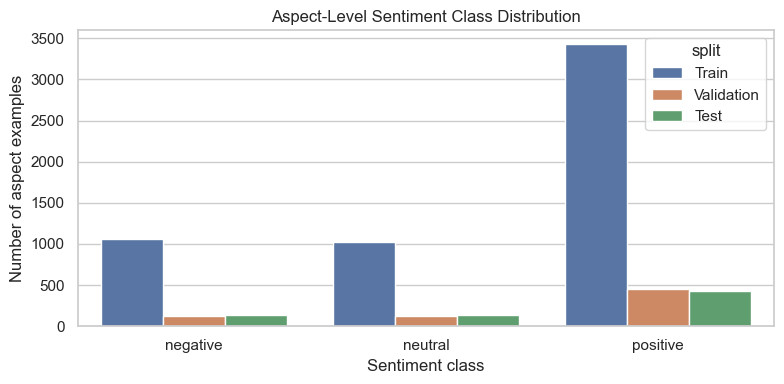

,model,split,accuracy,macro_f1
0,Majority baseline,Validation,0.6420,0.2607
1,Majority baseline,Test,0.6218,0.2556
2,TF-IDF + Logistic Regression,Validation,0.7131,0.6379
3,TF-IDF + Logistic Regression,Test,0.6834,0.6094


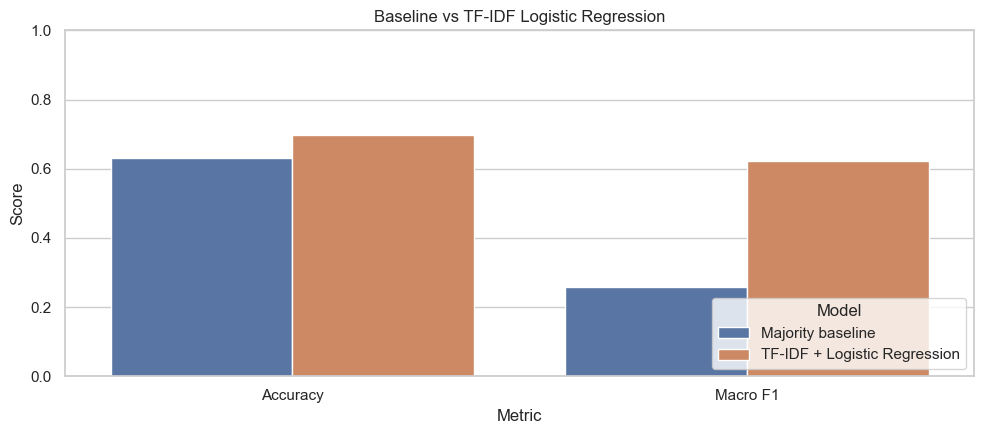

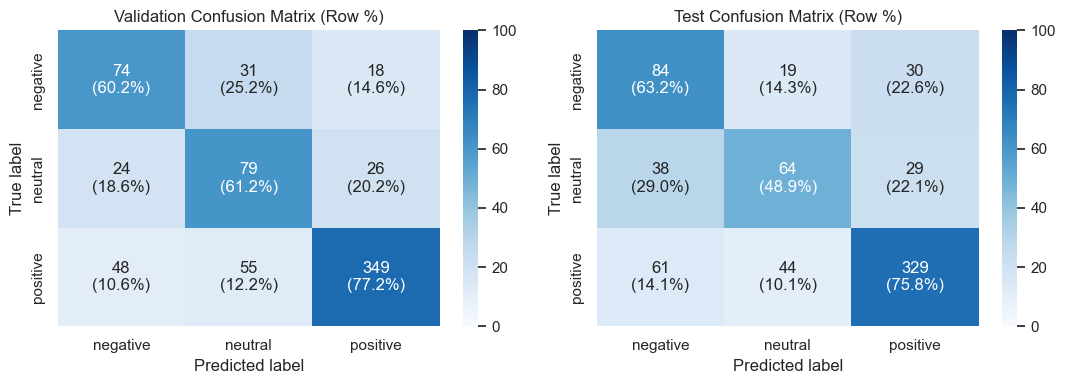

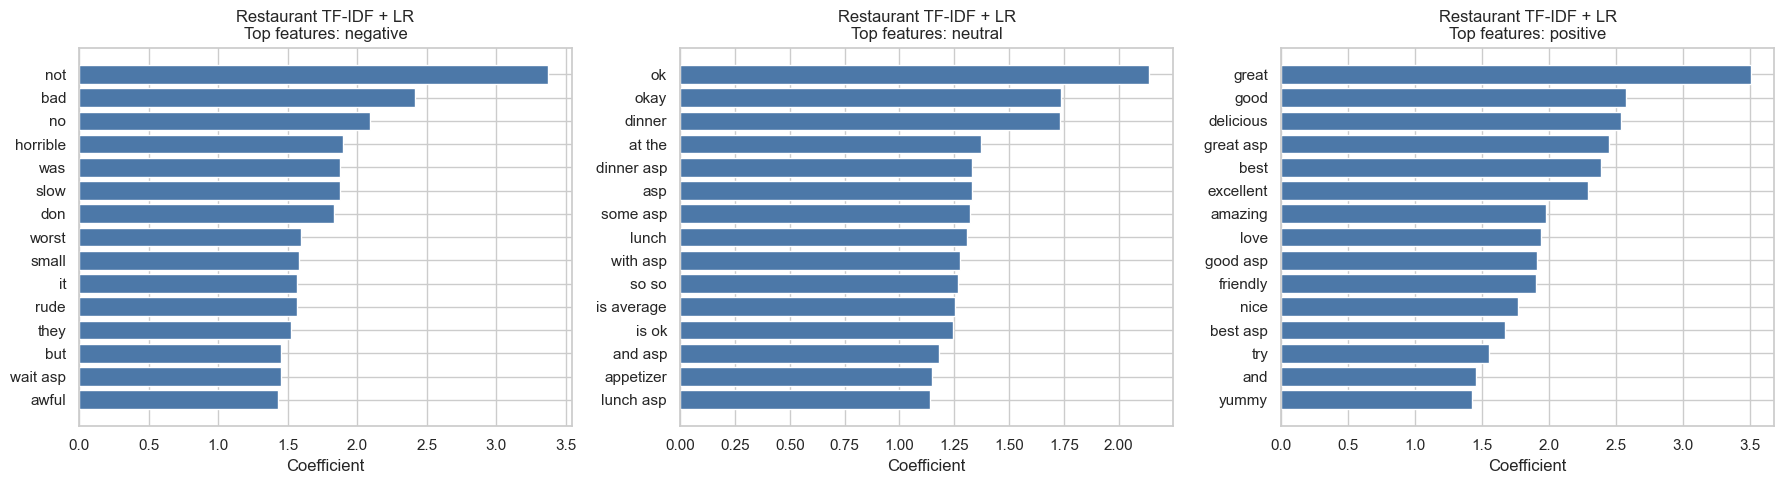

Computed SHAP values for 300 validation examples and 19888 TF-IDF features.
For this multiclass classifier, each feature has one SHAP value per sentiment class.
Global SHAP below uses signed mean SHAP values: positive values push toward the class, negative values push away from it.


,class,direction,rank,feature,mean_shap
15,negative,away,1,asp,-0.02646
16,negative,away,2,great,-0.02067
17,negative,away,3,delicious,-0.01366
18,negative,away,4,best,-0.01274
19,negative,away,5,not,-0.00962
...,...,...,...,...,...
70,positive,toward,11,asp,0.00799
71,positive,toward,12,from,0.00696
72,positive,toward,13,but,0.00652
73,positive,toward,14,ordered,0.00616


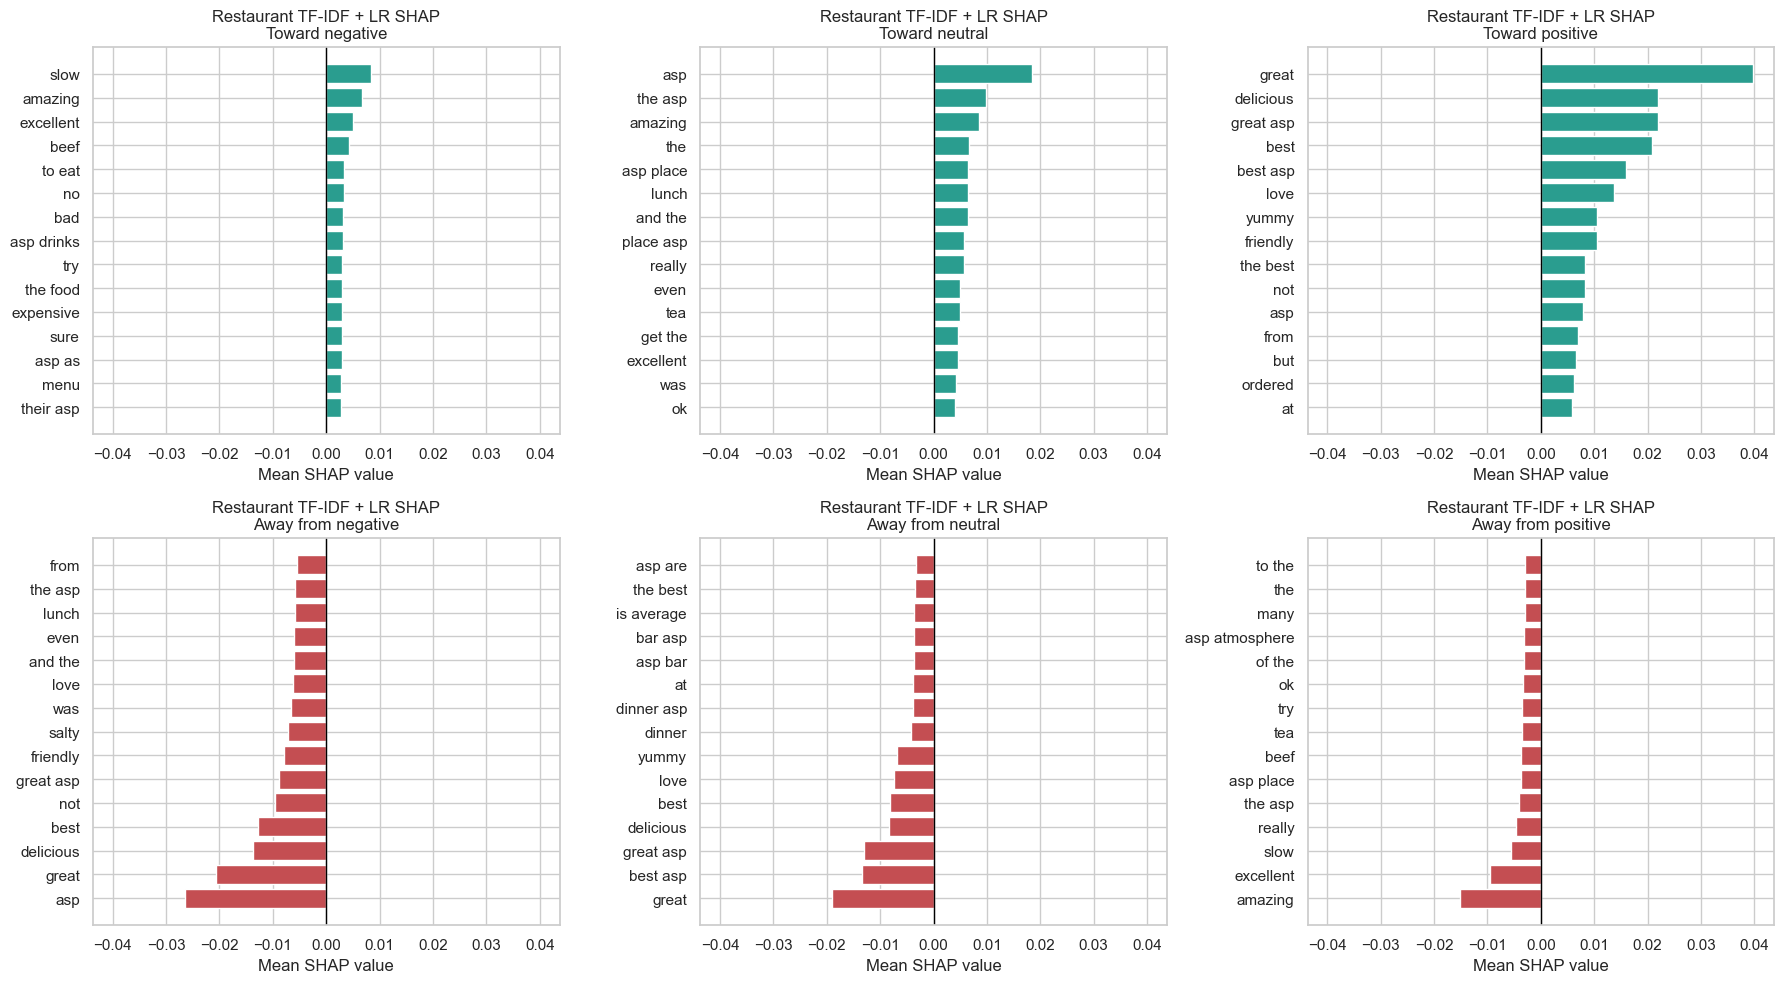


Local SHAP example from the restaurant test split
Aspect: staff
True label: positive
Predicted label: positive
Prediction probabilities:


,probability
negative,0.0251
neutral,0.0120
positive,0.9630


Text: Service and food was fantastic. The banana pie is amazing. Very attentive and friendly staff.
Positive SHAP values push the prediction toward the displayed predicted class; negative values push away from it.


,feature,tfidf,shap_value
0,amazing,0.15380,0.27612
13,friendly,0.14764,0.27420
6,attentive,0.19465,0.24003
9,fantastic,0.20385,0.18395
14,friendly asp,0.20909,0.15421
22,staff asp,0.17588,0.13437
16,is amazing,0.20551,0.13040
7,attentive and,0.22719,0.11756
21,staff,0.15211,0.10677
1,and,0.10097,0.10432


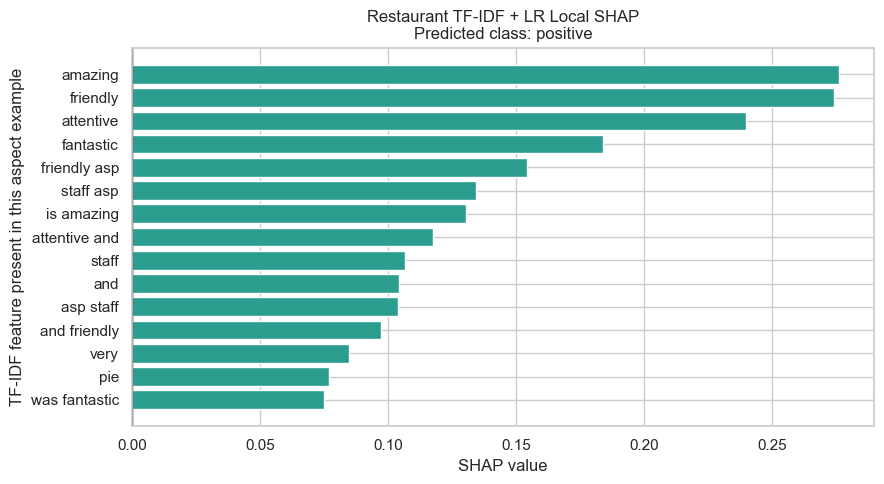

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap

from IPython.display import display
from sklearn.metrics import confusion_matrix

sns.set_theme(style="whitegrid")

id_to_label = dict(zip(label_ids, label_names))

# Class distribution by split
class_count_rows = []
for split_name, split_df in [
    ("Train", train_rest),
    ("Validation", val_rest),
    ("Test", test_rest),
]:
    counts = split_df["label"].map(id_to_label).value_counts().reindex(label_names, fill_value=0)
    for class_name, count in counts.items():
        class_count_rows.append({
            "split": split_name,
            "class": class_name,
            "count": int(count),
        })

class_counts_df = pd.DataFrame(class_count_rows)

plt.figure(figsize=(8, 4))
sns.barplot(
    data=class_counts_df,
    x="class",
    y="count",
    hue="split",
    order=label_names,
)
plt.title("Aspect-Level Sentiment Class Distribution")
plt.xlabel("Sentiment class")
plt.ylabel("Number of aspect examples")
plt.tight_layout()
plt.show()

# Accuracy and macro F1 comparison by split
val_pred_majority = majority_baseline.predict(val_rest[["model_input"]])
test_pred_majority = majority_baseline.predict(test_rest[["model_input"]])

metric_rows = []
for model_name, split_name, split_df, y_pred in [
    ("Majority baseline", "Validation", val_rest, val_pred_majority),
    ("Majority baseline", "Test", test_rest, test_pred_majority),
    ("TF-IDF + Logistic Regression", "Validation", val_rest, val_pred_tfidf_logreg),
    ("TF-IDF + Logistic Regression", "Test", test_rest, test_pred_tfidf_logreg),
]:
    y_true = split_df["label"]
    metric_rows.append({
        "model": model_name,
        "split": split_name,
        "accuracy": accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro"),
    })

metrics_df = pd.DataFrame(metric_rows)
display(metrics_df.round(4))

metrics_long_df = metrics_df.melt(
    id_vars=["model", "split"],
    value_vars=["accuracy", "macro_f1"],
    var_name="metric",
    value_name="score",
)
metrics_long_df["metric"] = metrics_long_df["metric"].map({
    "accuracy": "Accuracy",
    "macro_f1": "Macro F1",
})

plt.figure(figsize=(10, 4.5))
sns.barplot(
    data=metrics_long_df,
    x="metric",
    y="score",
    hue="model",
    errorbar=None,
)
plt.title("Baseline vs TF-IDF Logistic Regression")
plt.xlabel("Metric")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.legend(title="Model", loc="lower right")
plt.tight_layout()
plt.show()

# Confusion matrices for the TF-IDF classifier
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, split_name, split_df, y_pred in [
    (axes[0], "Validation", val_rest, val_pred_tfidf_logreg),
    (axes[1], "Test", test_rest, test_pred_tfidf_logreg),
]:
    cm = confusion_matrix(split_df["label"], y_pred, labels=label_ids)
    cm_pct = confusion_matrix(split_df["label"], y_pred, labels=label_ids, normalize="true") * 100
    cm_labels = np.array([
        [f"{count}\n({pct:.1f}%)" for count, pct in zip(count_row, pct_row)]
        for count_row, pct_row in zip(cm, cm_pct)
    ])
    sns.heatmap(
        cm_pct,
        annot=cm_labels,
        fmt="",
        cmap="Blues",
        vmin=0,
        vmax=100,
        xticklabels=label_names,
        yticklabels=label_names,
        ax=ax,
    )
    ax.set_title(f"{split_name} Confusion Matrix (Row %)")
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")

plt.tight_layout()
plt.show()

# Most positive Logistic Regression TF-IDF weights
vectorizer = tfidf_logreg_model.named_steps["tfidf"]
classifier = tfidf_logreg_model.named_steps["clf"]
feature_names = vectorizer.get_feature_names_out()

top_n = 15
fig, axes = plt.subplots(1, len(label_names), figsize=(18, 5))
for class_idx, class_name in enumerate(label_names):
    top_idx = np.argsort(classifier.coef_[class_idx])[-top_n:]
    coef_df = pd.DataFrame({
        "feature": feature_names[top_idx],
        "coefficient": classifier.coef_[class_idx][top_idx],
    }).sort_values("coefficient")

    axes[class_idx].barh(coef_df["feature"], coef_df["coefficient"], color="blue")
    axes[class_idx].set_title(f"Restaurant TF-IDF + LR\nTop features: {class_name}")
    axes[class_idx].set_xlabel("Coefficient")
    axes[class_idx].set_ylabel("")

plt.tight_layout()
plt.show()

# SHAP values for TF-IDF + Logistic Regression classifier
X_train_tfidf = vectorizer.transform(train_rest["model_input"])
X_val_tfidf = vectorizer.transform(val_rest["model_input"])

background_size = min(1000, X_train_tfidf.shape[0])
shap_sample_size = min(300, X_val_tfidf.shape[0])

rng = np.random.default_rng(RANDOM_SEED)
background_idx = rng.choice(X_train_tfidf.shape[0], size=background_size, replace=False)
X_background = X_train_tfidf[background_idx]
X_shap = X_val_tfidf[:shap_sample_size]
shap_source = val_rest.iloc[:shap_sample_size].copy()

explainer = shap.LinearExplainer(classifier, X_background, feature_names=feature_names)
shap_values = explainer(X_shap)

print(f"Computed SHAP values for {shap_sample_size} validation examples and {len(feature_names)} TF-IDF features.")
print("For this multiclass classifier, each feature has one SHAP value per sentiment class.")

# Global SHAP importance by class: signed mean SHAP value.
print("Global SHAP below uses signed mean SHAP values: positive values push toward the class, negative values push away from it.")
shap_top_rows = []
for class_idx, class_name in enumerate(label_names):
    class_values = shap_values.values[:, :, class_idx]
    mean_shap = class_values.mean(axis=0)
    toward_idx = np.argsort(mean_shap)[-top_n:][::-1]
    away_idx = np.argsort(mean_shap)[:top_n]

    for rank, feature_idx in enumerate(toward_idx, start=1):
        shap_top_rows.append({
            "class": class_name,
            "direction": "toward",
            "rank": rank,
            "feature": feature_names[feature_idx],
            "mean_shap": mean_shap[feature_idx],
        })

    for rank, feature_idx in enumerate(away_idx, start=1):
        shap_top_rows.append({
            "class": class_name,
            "direction": "away",
            "rank": rank,
            "feature": feature_names[feature_idx],
            "mean_shap": mean_shap[feature_idx],
        })

shap_top_df = pd.DataFrame(shap_top_rows).sort_values(["class", "direction", "rank"])
display(shap_top_df.round(5))

fig, axes = plt.subplots(2, len(label_names), figsize=(18, 10))
max_abs_shap = shap_top_df["mean_shap"].abs().max() * 1.1
for class_idx, class_name in enumerate(label_names):
    toward_df = shap_top_df[(shap_top_df["class"] == class_name) & (shap_top_df["direction"] == "toward")].sort_values("mean_shap")
    away_df = shap_top_df[(shap_top_df["class"] == class_name) & (shap_top_df["direction"] == "away")].sort_values("mean_shap")

    axes[0, class_idx].barh(toward_df["feature"], toward_df["mean_shap"], color="green")
    axes[0, class_idx].axvline(0, color="black", linewidth=1)
    axes[0, class_idx].set_xlim(-max_abs_shap, max_abs_shap)
    axes[0, class_idx].set_title(f"Restaurant TF-IDF + LR SHAP\nToward {class_name}")
    axes[0, class_idx].set_xlabel("Mean SHAP value")
    axes[0, class_idx].set_ylabel("")

    axes[1, class_idx].barh(away_df["feature"], away_df["mean_shap"], color="red")
    axes[1, class_idx].axvline(0, color="black", linewidth=1)
    axes[1, class_idx].set_xlim(-max_abs_shap, max_abs_shap)
    axes[1, class_idx].set_title(f"Restaurant TF-IDF + LR SHAP\nAway from {class_name}")
    axes[1, class_idx].set_xlabel("Mean SHAP value")
    axes[1, class_idx].set_ylabel("")

plt.tight_layout()
plt.show()

# Local SHAP explanation for one longer, strongly positive restaurant test aspect.
# Select a correctly predicted positive test example with at least 15 words.
X_local = vectorizer.transform(test_rest["model_input"])
sample_pred = classifier.predict(X_local)
sample_true = test_rest["label"].to_numpy()
sample_proba = classifier.predict_proba(X_local)
word_counts = test_rest["text"].astype(str).str.split().str.len().to_numpy()
positive_class = label_names.index("positive")
positive_candidates = np.flatnonzero(
    (sample_true == positive_class) &
    (sample_pred == positive_class) &
    (word_counts >= 15)
)
fallback_positive_candidates = np.flatnonzero((sample_true == positive_class) & (sample_pred == positive_class))

if len(positive_candidates):
    best_positive_position = np.argmax(sample_proba[positive_candidates, positive_class])
    example_idx = int(positive_candidates[best_positive_position])
elif len(fallback_positive_candidates):
    best_positive_position = np.argmax(sample_proba[fallback_positive_candidates, positive_class])
    example_idx = int(fallback_positive_candidates[best_positive_position])
else:
    example_idx = int(np.argmax(sample_proba[:, positive_class]))

predicted_class = int(sample_pred[example_idx])
true_class = int(sample_true[example_idx])
pred_probs = sample_proba[example_idx]
local_shap_values = explainer(X_local[example_idx])

print("\nLocal SHAP example from the restaurant test split")
print(f"Aspect: {test_rest.iloc[example_idx]['target']}")
print(f"True label: {id_to_label[true_class]}")
print(f"Predicted label: {id_to_label[predicted_class]}")
print("Prediction probabilities:")
display(pd.Series(pred_probs, index=label_names).round(4).to_frame("probability"))
print(f"Text: {test_rest.iloc[example_idx]['text']}")
print("Positive SHAP values push the prediction toward the displayed predicted class; negative values push away from it.")

row_tfidf = X_local[example_idx].toarray().ravel()
present_idx = np.flatnonzero(row_tfidf)
local_values = local_shap_values.values[0, :, predicted_class]

local_shap_df = pd.DataFrame({
    "feature": feature_names[present_idx],
    "tfidf": row_tfidf[present_idx],
    "shap_value": local_values[present_idx],
})
local_shap_df["abs_shap"] = local_shap_df["shap_value"].abs()
local_shap_df = local_shap_df.sort_values("abs_shap", ascending=False).head(top_n)
display(local_shap_df[["feature", "tfidf", "shap_value"]].round(5))

plot_df = local_shap_df.sort_values("shap_value")
colors = np.where(plot_df["shap_value"] >= 0, "green", "red")

plt.figure(figsize=(9, 5))
plt.barh(plot_df["feature"], plot_df["shap_value"], color=colors)
plt.axvline(0, color="black", linewidth=1)
plt.title(f"Restaurant TF-IDF + LR Local SHAP\nPredicted class: {id_to_label[predicted_class]}")
plt.xlabel("SHAP value")
plt.ylabel("TF-IDF feature present in this aspect example")
plt.tight_layout()
plt.show()


## **3.2 Laptop Dataset**

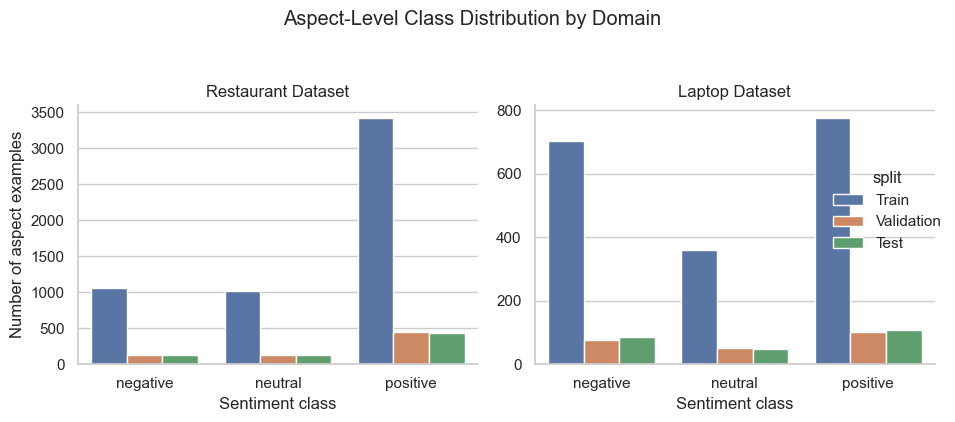

Restaurant-trained TF-IDF + Logistic Regression on Laptop Test
Accuracy : 0.7008
Macro F1 : 0.6641
              precision    recall  f1-score   support

    negative     0.6355    0.7816    0.7010        87
     neutral     0.7407    0.4167    0.5333        48
    positive     0.7545    0.7615    0.7580       109

    accuracy                         0.7008       244
   macro avg     0.7103    0.6532    0.6641       244
weighted avg     0.7094    0.7008    0.6935       244



,model,train_data,eval_domain,split,accuracy,macro_f1
0,Restaurant TF-IDF + LR,Restaurant,Restaurant,Test,0.6834,0.6094
1,Restaurant TF-IDF + LR,Restaurant,Laptop,Test,0.7008,0.6641
2,Combined majority,Restaurant + Laptop,Restaurant,Test,0.6218,0.2556
3,Combined majority,Restaurant + Laptop,Laptop,Test,0.4467,0.2059
4,Combined TF-IDF + LR,Restaurant + Laptop,Restaurant,Validation,0.7244,0.6477
5,Combined TF-IDF + LR,Restaurant + Laptop,Restaurant,Test,0.7020,0.6289
6,Combined TF-IDF + LR,Restaurant + Laptop,Laptop,Validation,0.6564,0.6073
7,Combined TF-IDF + LR,Restaurant + Laptop,Laptop,Test,0.6639,0.6274


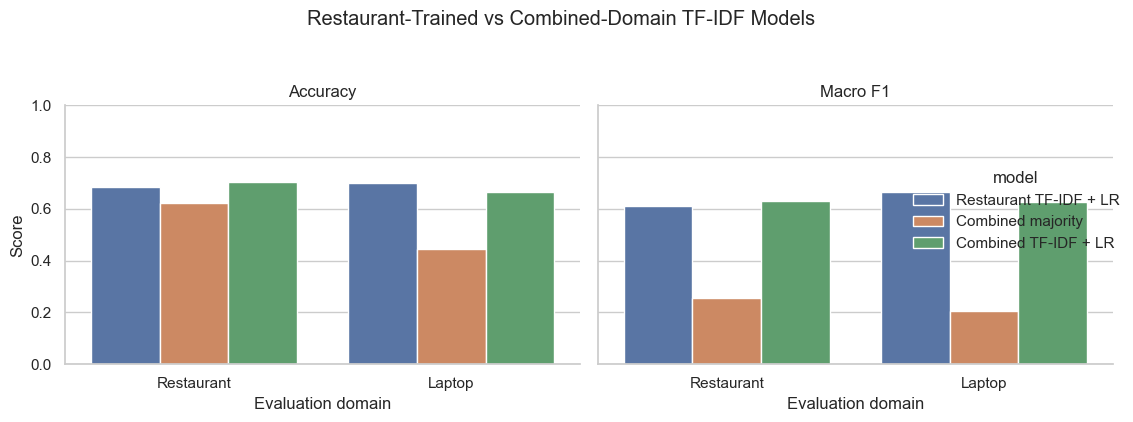

,scenario,macro_f1
0,Restaurant model\non restaurant,0.6094
1,Restaurant model\non laptop,0.6641
2,Restaurant + laptop model\non restaurant,0.6289
3,Restaurant + laptop model\non laptop,0.6274


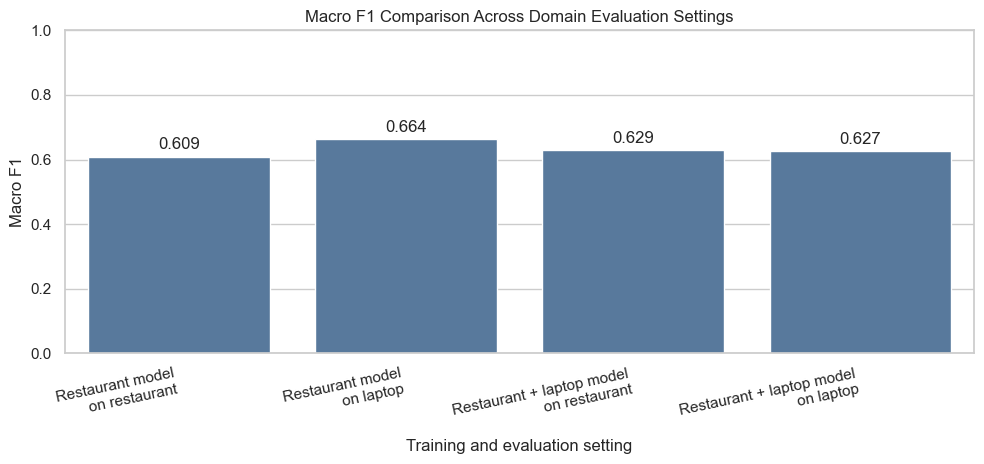

,model,eval_split,class,precision,recall,f1_score,support
0,Restaurant TF-IDF + LR,Restaurant Test,negative,0.4590,0.6316,0.5316,133
1,Restaurant TF-IDF + LR,Restaurant Test,neutral,0.5039,0.4885,0.4961,131
2,Restaurant TF-IDF + LR,Restaurant Test,positive,0.8479,0.7581,0.8005,434
3,Restaurant TF-IDF + LR,Laptop Test,negative,0.6355,0.7816,0.7010,87
4,Restaurant TF-IDF + LR,Laptop Test,neutral,0.7407,0.4167,0.5333,48
5,Restaurant TF-IDF + LR,Laptop Test,positive,0.7545,0.7615,0.7580,109
6,Combined TF-IDF + LR,Restaurant Test,negative,0.5060,0.6316,0.5619,133
7,Combined TF-IDF + LR,Restaurant Test,neutral,0.5037,0.5191,0.5113,131
8,Combined TF-IDF + LR,Restaurant Test,positive,0.8514,0.7788,0.8135,434
9,Combined TF-IDF + LR,Laptop Test,negative,0.6283,0.8161,0.7100,87


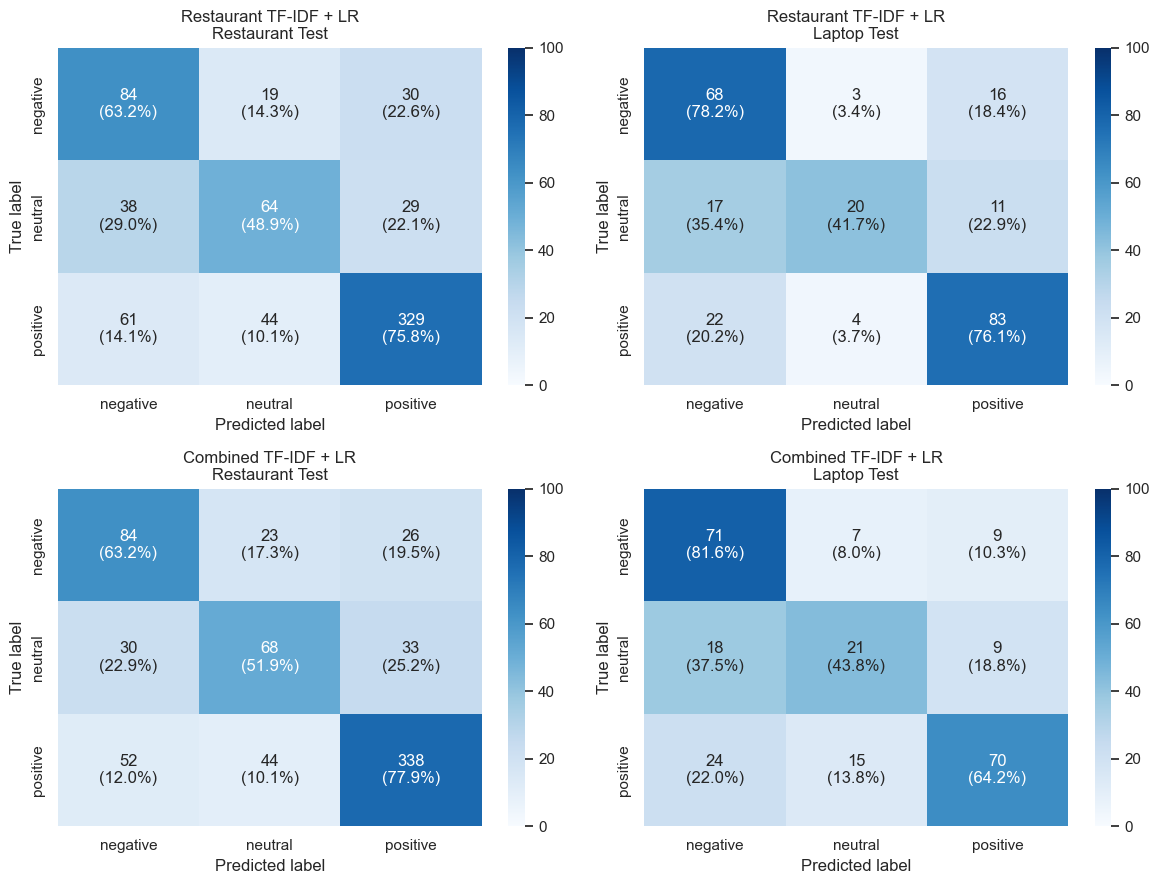

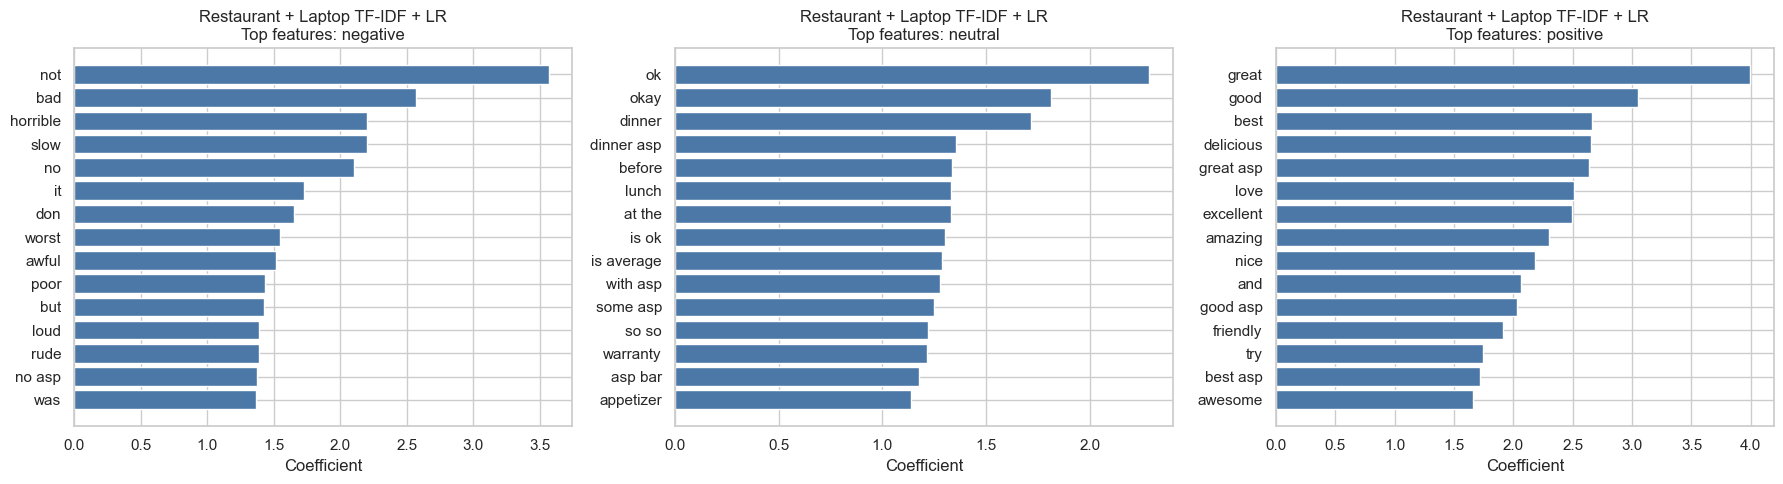

Computed SHAP values for 300 restaurant/laptop test examples and 26354 TF-IDF features.
Global SHAP below uses signed mean SHAP values: positive values push toward the class, negative values push away from it.


,class,direction,rank,feature,mean_shap
15,negative,away,1,asp,-0.01546
16,negative,away,2,great,-0.01016
17,negative,away,3,good,-0.00900
18,negative,away,4,awesome,-0.00832
19,negative,away,5,and asp,-0.00750
...,...,...,...,...,...
70,positive,toward,11,perfect,0.00598
71,positive,toward,12,asp,0.00558
72,positive,toward,13,have to,0.00549
73,positive,toward,14,cool,0.00500


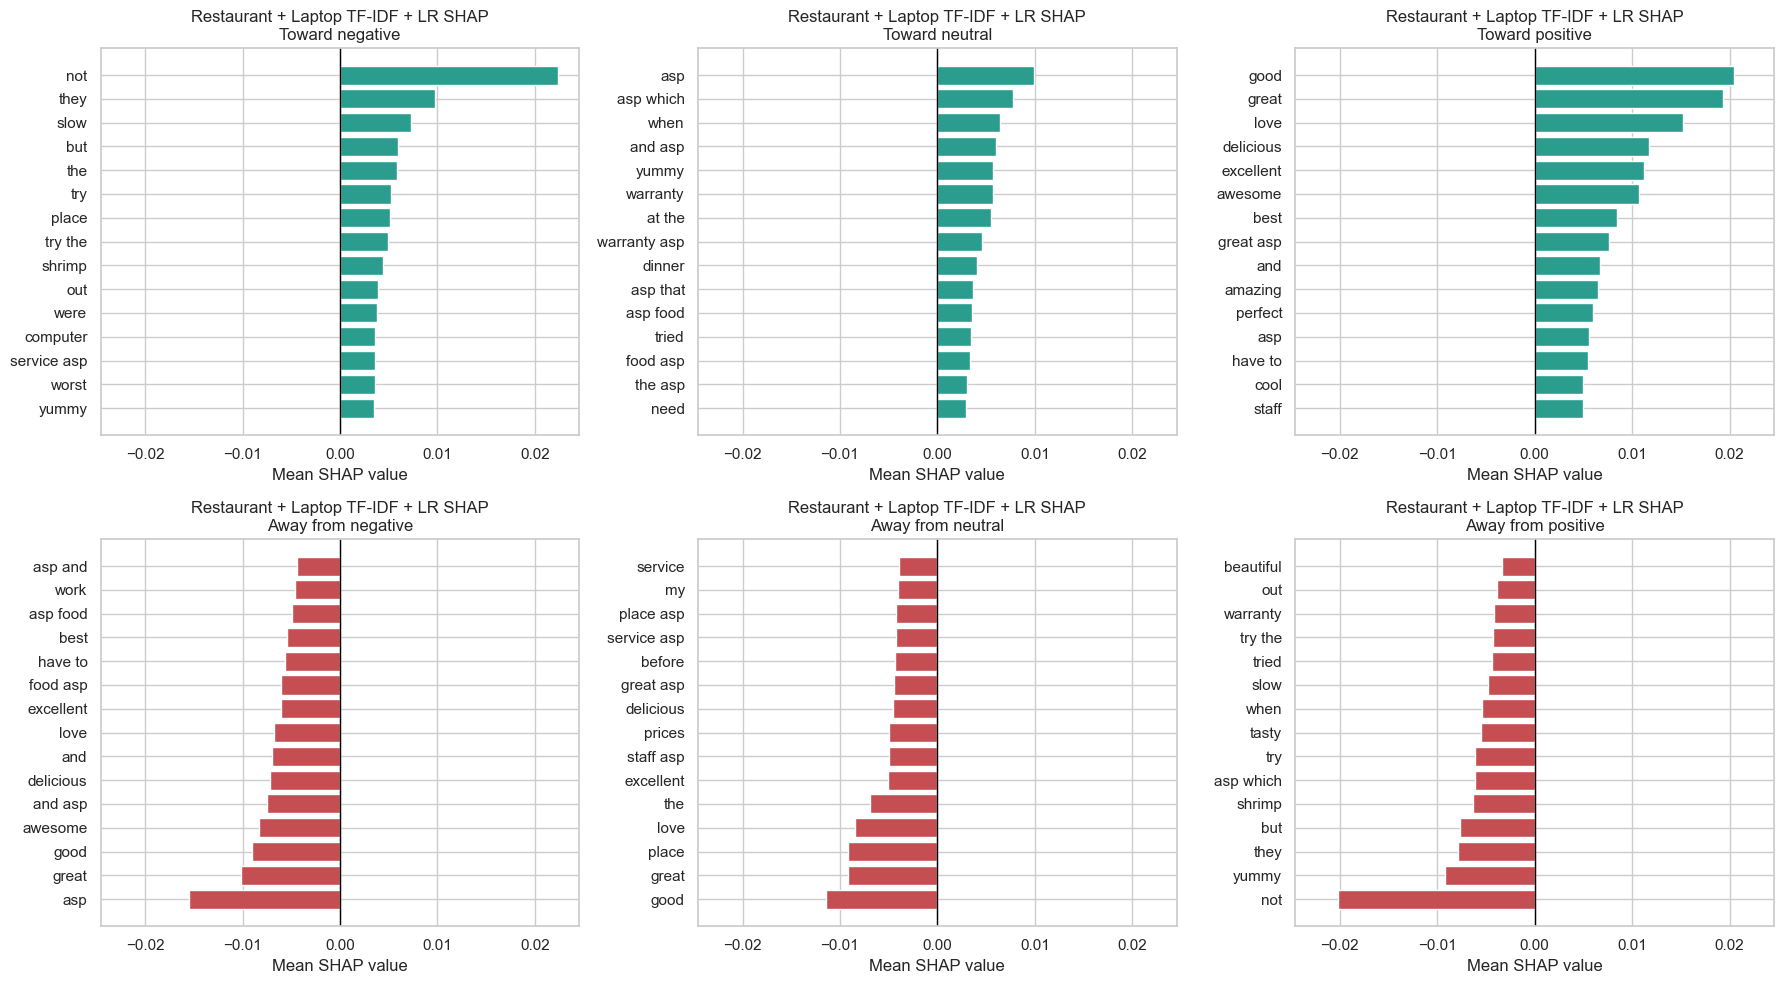


Local SHAP example from the laptop test split
Aspect: quality
True label: positive
Predicted label: positive
Prediction probabilities:


,probability
negative,0.0197
neutral,0.0133
positive,0.9671


Text: It is easy to use, good quality and good price.
Positive SHAP values push the prediction toward the displayed predicted class; negative values push away from it.


,feature,tfidf,shap_value
7,good,0.25471,0.72913
8,good asp,0.22587,0.44446
5,easy,0.23940,0.34002
6,easy to,0.25678,0.22996
1,and good,0.29306,0.14498
3,asp and,0.14964,0.11506
14,price,0.19769,0.10309
0,and,0.07741,0.09776
18,to use,0.27009,0.08841
17,to,0.10673,-0.08533


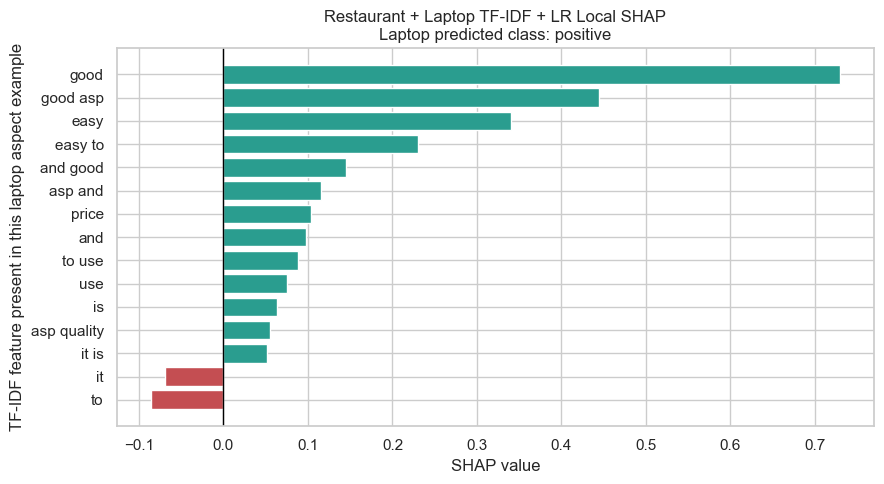

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap

from IPython.display import display
from sklearn.dummy import DummyClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, accuracy_score, f1_score, confusion_matrix

sns.set_theme(style="whitegrid")

required_31_names = [
    "tfidf_logreg_model",
    "mark_aspect",
    "train_rest",
    "val_rest",
    "test_rest",
    "label_ids",
    "label_names",
    "label_map",
    "RANDOM_SEED",
]
missing_31_names = [name for name in required_31_names if name not in globals()]
if missing_31_names:
    raise RuntimeError(
        "Run section 3.1.1 first. Missing variables: " + ", ".join(missing_31_names)
    )

id_to_label = dict(zip(label_ids, label_names))


def prepare_absa_split(split_df):
    """Ensure a split has numeric labels and aspect-marked model inputs."""
    split_df = split_df.copy()

    if "label" not in split_df.columns:
        split_df["label"] = split_df["polarity"].map(label_map)

    split_df["label"] = split_df["label"].astype(int)

    if "model_input" not in split_df.columns:
        split_df["model_input"] = split_df.apply(mark_aspect, axis=1)

    return split_df


# Load laptop splits and make sure restaurant splits use the same prepared format.
DATA_PATH = Path(__file__).resolve().parent.parent.parent.parent
train_lap = prepare_absa_split(pd.read_csv(DATA_PATH / "data/semeval2014/laptop/processed/train.csv"))
val_lap = prepare_absa_split(pd.read_csv(DATA_PATH / "data/semeval2014/laptop/processed/val.csv"))
test_lap = prepare_absa_split(pd.read_csv(DATA_PATH / "data/semeval2014/laptop/processed/test.csv"))

train_rest = prepare_absa_split(train_rest)
val_rest = prepare_absa_split(val_rest)
test_rest = prepare_absa_split(test_rest)

# Class distribution for restaurant and laptop data
class_count_rows = []
for domain_name, split_items in [
    ("Restaurant", [("Train", train_rest), ("Validation", val_rest), ("Test", test_rest)]),
    ("Laptop", [("Train", train_lap), ("Validation", val_lap), ("Test", test_lap)]),
]:
    for split_name, split_df in split_items:
        counts = split_df["label"].map(id_to_label).value_counts().reindex(label_names, fill_value=0)
        for class_name, count in counts.items():
            class_count_rows.append({
                "domain": domain_name,
                "split": split_name,
                "class": class_name,
                "count": int(count),
            })

class_counts_domain_df = pd.DataFrame(class_count_rows)

g = sns.catplot(
    data=class_counts_domain_df,
    kind="bar",
    x="class",
    y="count",
    hue="split",
    col="domain",
    order=label_names,
    sharey=False,
    height=4,
    aspect=1.05,
)
g.set_axis_labels("Sentiment class", "Number of aspect examples")
g.set_titles("{col_name} Dataset")
g.fig.suptitle("Aspect-Level Class Distribution by Domain", y=1.05)
plt.tight_layout()
plt.show()

# Cross-domain evaluation: section 3.1 restaurant model on laptop
laptop_test_pred_restaurant_model = tfidf_logreg_model.predict(test_lap["model_input"])

print("Restaurant-trained TF-IDF + Logistic Regression on Laptop Test")
print(f"Accuracy : {accuracy_score(test_lap['label'], laptop_test_pred_restaurant_model):.4f}")
print(f"Macro F1 : {f1_score(test_lap['label'], laptop_test_pred_restaurant_model, average='macro'):.4f}")
print(classification_report(
    test_lap["label"],
    laptop_test_pred_restaurant_model,
    labels=label_ids,
    target_names=label_names,
    digits=4,
    zero_division=0,
))

# Train a new TF-IDF model on restaurant + laptop training data
combined_train_df = pd.concat([
    train_rest.assign(training_domain="Restaurant"),
    train_lap.assign(training_domain="Laptop"),
], ignore_index=True)

combined_majority_baseline = DummyClassifier(strategy="most_frequent")
combined_majority_baseline.fit(combined_train_df[["model_input"]], combined_train_df["label"])

combined_tfidf_logreg_model = Pipeline([
    ("tfidf", TfidfVectorizer(
        ngram_range=(1, 2),
        min_df=2,
        sublinear_tf=True,
        lowercase=True,
    )),
    ("clf", LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=RANDOM_SEED,
    )),
])

combined_tfidf_logreg_model.fit(combined_train_df["model_input"], combined_train_df["label"])

restaurant_val_pred_combined = combined_tfidf_logreg_model.predict(val_rest["model_input"])
restaurant_test_pred_combined = combined_tfidf_logreg_model.predict(test_rest["model_input"])
laptop_val_pred_combined = combined_tfidf_logreg_model.predict(val_lap["model_input"])
laptop_test_pred_combined = combined_tfidf_logreg_model.predict(test_lap["model_input"])

restaurant_test_pred_combined_majority = combined_majority_baseline.predict(test_rest[["model_input"]])
laptop_test_pred_combined_majority = combined_majority_baseline.predict(test_lap[["model_input"]])

# Save misclassified rows for the requested test scenarios
MISCLASSIFICATION_DIR = Path("experiments/misclassifications")
MISCLASSIFICATION_DIR.mkdir(parents=True, exist_ok=True)

def save_misclassifications(split_df, y_pred, output_name):
    y_pred = np.asarray(y_pred)
    output_df = split_df.copy()
    output_df["ML"] = pd.Series(y_pred, index=output_df.index).map(id_to_label)
    misclassified_df = output_df[output_df["label"].to_numpy() != y_pred].copy()

    if "model_input" in misclassified_df.columns:
        misclassified_df = misclassified_df.drop(columns=["model_input"])

    output_path = MISCLASSIFICATION_DIR / output_name
    misclassified_df.to_csv(output_path, index=False)
    print(f"Saved {len(misclassified_df)} misclassifications to {output_path}")
    return misclassified_df

combined_test_df = pd.concat([
    test_rest.assign(eval_domain="Restaurant"),
    test_lap.assign(eval_domain="Laptop"),
], ignore_index=True)
combined_test_pred_combined = np.concatenate([
    restaurant_test_pred_combined,
    laptop_test_pred_combined,
])

misclassification_exports = {
    "rest_model_on_rest": save_misclassifications(
        test_rest,
        test_pred_tfidf_logreg,
        "rest_model_on_rest_misclassifications.csv",
    ),
    "rest_model_on_laptop": save_misclassifications(
        test_lap,
        laptop_test_pred_restaurant_model,
        "rest_model_on_laptop_misclassifications.csv",
    ),
    "combined_model_on_rest": save_misclassifications(
        test_rest,
        restaurant_test_pred_combined,
        "combined_model_on_rest_misclassifications.csv",
    ),
    "combined_model_on_rest_laptop": save_misclassifications(
        combined_test_df,
        combined_test_pred_combined,
        "combined_model_on_rest_laptop_misclassifications.csv",
    ),
}

# Metrics table and comparison plot
metric_rows = []

def add_metric_row(model_name, train_data, eval_domain, split_name, split_df, y_pred):
    y_true = split_df["label"]
    metric_rows.append({
        "model": model_name,
        "train_data": train_data,
        "eval_domain": eval_domain,
        "split": split_name,
        "accuracy": accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro"),
    })


add_metric_row(
    "Restaurant TF-IDF + LR",
    "Restaurant",
    "Restaurant",
    "Test",
    test_rest,
    test_pred_tfidf_logreg,
)
add_metric_row(
    "Restaurant TF-IDF + LR",
    "Restaurant",
    "Laptop",
    "Test",
    test_lap,
    laptop_test_pred_restaurant_model,
)
add_metric_row(
    "Combined majority",
    "Restaurant + Laptop",
    "Restaurant",
    "Test",
    test_rest,
    restaurant_test_pred_combined_majority,
)
add_metric_row(
    "Combined majority",
    "Restaurant + Laptop",
    "Laptop",
    "Test",
    test_lap,
    laptop_test_pred_combined_majority,
)
add_metric_row(
    "Combined TF-IDF + LR",
    "Restaurant + Laptop",
    "Restaurant",
    "Validation",
    val_rest,
    restaurant_val_pred_combined,
)
add_metric_row(
    "Combined TF-IDF + LR",
    "Restaurant + Laptop",
    "Restaurant",
    "Test",
    test_rest,
    restaurant_test_pred_combined,
)
add_metric_row(
    "Combined TF-IDF + LR",
    "Restaurant + Laptop",
    "Laptop",
    "Validation",
    val_lap,
    laptop_val_pred_combined,
)
add_metric_row(
    "Combined TF-IDF + LR",
    "Restaurant + Laptop",
    "Laptop",
    "Test",
    test_lap,
    laptop_test_pred_combined,
)
add_metric_row(
    "Combined TF-IDF + LR",
    "Restaurant + Laptop",
    "Restaurant + Laptop",
    "Test",
    combined_test_df,
    combined_test_pred_combined,
)

metrics_32_df = pd.DataFrame(metric_rows)
display(metrics_32_df.round(4))

metrics_32_test_long_df = metrics_32_df[metrics_32_df["split"] == "Test"].melt(
    id_vars=["model", "train_data", "eval_domain", "split"],
    value_vars=["accuracy", "macro_f1"],
    var_name="metric",
    value_name="score",
)
metrics_32_test_long_df["metric"] = metrics_32_test_long_df["metric"].map({
    "accuracy": "Accuracy",
    "macro_f1": "Macro F1",
})

g = sns.catplot(
    data=metrics_32_test_long_df,
    kind="bar",
    x="eval_domain",
    y="score",
    hue="model",
    col="metric",
    errorbar=None,
    height=4,
    aspect=1.15,
)
g.set_axis_labels("Evaluation domain", "Score")
g.set_titles("{col_name}")
g.set(ylim=(0, 1))
g.fig.suptitle("Restaurant-Trained vs Combined-Domain TF-IDF Models", y=1.05)
plt.tight_layout()
plt.show()

# Dedicated macro F1 comparison for the four requested test-set scenarios.
f1_comparison_df = pd.DataFrame([
    {
        "scenario": "Restaurant model\non restaurant",
        "macro_f1": f1_score(test_rest["label"], test_pred_tfidf_logreg, average="macro"),
    },
    {
        "scenario": "Restaurant model\non laptop",
        "macro_f1": f1_score(test_lap["label"], laptop_test_pred_restaurant_model, average="macro"),
    },
    {
        "scenario": "Restaurant + laptop model\non restaurant",
        "macro_f1": f1_score(test_rest["label"], restaurant_test_pred_combined, average="macro"),
    },
    {
        "scenario": "Restaurant + laptop model\non restaurant + laptop",
        "macro_f1": f1_score(combined_test_df["label"], combined_test_pred_combined, average="macro"),
    },
])

display(f1_comparison_df.round(4))

plt.figure(figsize=(10, 4.8))
ax = sns.barplot(
    data=f1_comparison_df,
    x="scenario",
    y="macro_f1",
    color="blue",
)
ax.bar_label(ax.containers[0], fmt="%.3f", padding=3)
plt.title("Macro F1 Comparison Across Domain Evaluation Settings")
plt.xlabel("Training and evaluation setting")
plt.ylabel("Macro F1")
plt.ylim(0, 1)
plt.xticks(rotation=12, ha="right")
plt.tight_layout()
plt.show()

# Per-class report table for the main test-set comparisons.
report_rows = []
for model_name, eval_domain, split_df, y_pred in [
    ("Restaurant TF-IDF + LR", "Restaurant Test", test_rest, test_pred_tfidf_logreg),
    ("Restaurant TF-IDF + LR", "Laptop Test", test_lap, laptop_test_pred_restaurant_model),
    ("Combined TF-IDF + LR", "Restaurant Test", test_rest, restaurant_test_pred_combined),
    ("Combined TF-IDF + LR", "Laptop Test", test_lap, laptop_test_pred_combined),
]:
    report = classification_report(
        split_df["label"],
        y_pred,
        labels=label_ids,
        target_names=label_names,
        output_dict=True,
        zero_division=0,
    )
    for class_name in label_names:
        report_rows.append({
            "model": model_name,
            "eval_split": eval_domain,
            "class": class_name,
            "precision": report[class_name]["precision"],
            "recall": report[class_name]["recall"],
            "f1_score": report[class_name]["f1-score"],
            "support": int(report[class_name]["support"]),
        })

report_32_df = pd.DataFrame(report_rows)
display(report_32_df.round(4))

# Confusion matrices for the main test-set comparisons
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
confusion_items = [
    (axes[0, 0], "Restaurant TF-IDF + LR\nRestaurant Test", test_rest, test_pred_tfidf_logreg),
    (axes[0, 1], "Restaurant TF-IDF + LR\nLaptop Test", test_lap, laptop_test_pred_restaurant_model),
    (axes[1, 0], "Combined TF-IDF + LR\nRestaurant Test", test_rest, restaurant_test_pred_combined),
    (axes[1, 1], "Combined TF-IDF + LR\nLaptop Test", test_lap, laptop_test_pred_combined),
]

for ax, title, split_df, y_pred in confusion_items:
    cm = confusion_matrix(split_df["label"], y_pred, labels=label_ids)
    cm_pct = confusion_matrix(split_df["label"], y_pred, labels=label_ids, normalize="true") * 100
    cm_labels = np.array([
        [f"{count}\n({pct:.1f}%)" for count, pct in zip(count_row, pct_row)]
        for count_row, pct_row in zip(cm, cm_pct)
    ])
    sns.heatmap(
        cm_pct,
        annot=cm_labels,
        fmt="",
        cmap="Blues",
        vmin=0,
        vmax=100,
        xticklabels=label_names,
        yticklabels=label_names,
        ax=ax,
    )
    ax.set_title(title)
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")

plt.tight_layout()
plt.show()

# Top Logistic Regression TF-IDF weights in the combined model
combined_vectorizer = combined_tfidf_logreg_model.named_steps["tfidf"]
combined_classifier = combined_tfidf_logreg_model.named_steps["clf"]
combined_feature_names = combined_vectorizer.get_feature_names_out()

top_n = 15
fig, axes = plt.subplots(1, len(label_names), figsize=(18, 5))
for class_idx, class_name in enumerate(label_names):
    top_idx = np.argsort(combined_classifier.coef_[class_idx])[-top_n:]
    coef_df = pd.DataFrame({
        "feature": combined_feature_names[top_idx],
        "coefficient": combined_classifier.coef_[class_idx][top_idx],
    }).sort_values("coefficient")

    axes[class_idx].barh(coef_df["feature"], coef_df["coefficient"], color="blue")
    axes[class_idx].set_title(f"Restaurant + Laptop TF-IDF + LR\nTop features: {class_name}")
    axes[class_idx].set_xlabel("Coefficient")
    axes[class_idx].set_ylabel("")

plt.tight_layout()
plt.show()

# SHAP values for the combined-domain TF-IDF model
X_combined_train_tfidf = combined_vectorizer.transform(combined_train_df["model_input"])
combined_eval_df = pd.concat([
    test_rest.assign(eval_domain="Restaurant"),
    test_lap.assign(eval_domain="Laptop"),
], ignore_index=True)

background_size = min(1000, X_combined_train_tfidf.shape[0])
shap_sample_size = min(300, combined_eval_df.shape[0])

rng = np.random.default_rng(RANDOM_SEED)
background_idx = rng.choice(X_combined_train_tfidf.shape[0], size=background_size, replace=False)
shap_source_32 = combined_eval_df.sample(n=shap_sample_size, random_state=RANDOM_SEED).reset_index(drop=True)

X_background_32 = X_combined_train_tfidf[background_idx]
X_shap_32 = combined_vectorizer.transform(shap_source_32["model_input"])

combined_explainer = shap.LinearExplainer(
    combined_classifier,
    X_background_32,
    feature_names=combined_feature_names,
)
shap_values_32 = combined_explainer(X_shap_32)

print(f"Computed SHAP values for {shap_sample_size} restaurant/laptop test examples and {len(combined_feature_names)} TF-IDF features.")

print("Global SHAP below uses signed mean SHAP values: positive values push toward the class, negative values push away from it.")
shap_top_rows = []
for class_idx, class_name in enumerate(label_names):
    class_values = shap_values_32.values[:, :, class_idx]
    mean_shap = class_values.mean(axis=0)
    toward_idx = np.argsort(mean_shap)[-top_n:][::-1]
    away_idx = np.argsort(mean_shap)[:top_n]

    for rank, feature_idx in enumerate(toward_idx, start=1):
        shap_top_rows.append({
            "class": class_name,
            "direction": "toward",
            "rank": rank,
            "feature": combined_feature_names[feature_idx],
            "mean_shap": mean_shap[feature_idx],
        })

    for rank, feature_idx in enumerate(away_idx, start=1):
        shap_top_rows.append({
            "class": class_name,
            "direction": "away",
            "rank": rank,
            "feature": combined_feature_names[feature_idx],
            "mean_shap": mean_shap[feature_idx],
        })

shap_top_32_df = pd.DataFrame(shap_top_rows).sort_values(["class", "direction", "rank"])
display(shap_top_32_df.round(5))

fig, axes = plt.subplots(2, len(label_names), figsize=(18, 10))
max_abs_shap_32 = shap_top_32_df["mean_shap"].abs().max() * 1.1
for class_idx, class_name in enumerate(label_names):
    toward_df = shap_top_32_df[(shap_top_32_df["class"] == class_name) & (shap_top_32_df["direction"] == "toward")].sort_values("mean_shap")
    away_df = shap_top_32_df[(shap_top_32_df["class"] == class_name) & (shap_top_32_df["direction"] == "away")].sort_values("mean_shap")

    axes[0, class_idx].barh(toward_df["feature"], toward_df["mean_shap"], color="green")
    axes[0, class_idx].axvline(0, color="black", linewidth=1)
    axes[0, class_idx].set_xlim(-max_abs_shap_32, max_abs_shap_32)
    axes[0, class_idx].set_title(f"Restaurant + Laptop TF-IDF + LR SHAP\nToward {class_name}")
    axes[0, class_idx].set_xlabel("Mean SHAP value")
    axes[0, class_idx].set_ylabel("")

    axes[1, class_idx].barh(away_df["feature"], away_df["mean_shap"], color="red")
    axes[1, class_idx].axvline(0, color="black", linewidth=1)
    axes[1, class_idx].set_xlim(-max_abs_shap_32, max_abs_shap_32)
    axes[1, class_idx].set_title(f"Restaurant + Laptop TF-IDF + LR SHAP\nAway from {class_name}")
    axes[1, class_idx].set_xlabel("Mean SHAP value")
    axes[1, class_idx].set_ylabel("")

plt.tight_layout()
plt.show()

# Local SHAP explanation for the strongest correctly predicted positive laptop test aspect.
X_laptop_test_combined = combined_vectorizer.transform(test_lap["model_input"])
laptop_test_proba_combined = combined_classifier.predict_proba(X_laptop_test_combined)
positive_class = label_names.index("positive")
positive_candidates = np.flatnonzero(
    (test_lap["label"].to_numpy() == positive_class) &
    (laptop_test_pred_combined == positive_class)
)

if len(positive_candidates):
    best_positive_position = np.argmax(laptop_test_proba_combined[positive_candidates, positive_class])
    local_idx = int(positive_candidates[best_positive_position])
else:
    local_idx = int(np.argmax(laptop_test_proba_combined[:, positive_class]))

local_predicted_class = int(laptop_test_pred_combined[local_idx])
local_true_class = int(test_lap.iloc[local_idx]["label"])
local_pred_probs = laptop_test_proba_combined[local_idx]
local_shap_values = combined_explainer(X_laptop_test_combined[local_idx])

print("\nLocal SHAP example from the laptop test split")
print(f"Aspect: {test_lap.iloc[local_idx]['target']}")
print(f"True label: {id_to_label[local_true_class]}")
print(f"Predicted label: {id_to_label[local_predicted_class]}")
print("Prediction probabilities:")
display(pd.Series(local_pred_probs, index=label_names).round(4).to_frame("probability"))
print(f"Text: {test_lap.iloc[local_idx]['text']}")
print("Positive SHAP values push the prediction toward the displayed predicted class; negative values push away from it.")

row_tfidf = X_laptop_test_combined[local_idx].toarray().ravel()
present_idx = np.flatnonzero(row_tfidf)
local_values = local_shap_values.values[0, :, local_predicted_class]

local_shap_32_df = pd.DataFrame({
    "feature": combined_feature_names[present_idx],
    "tfidf": row_tfidf[present_idx],
    "shap_value": local_values[present_idx],
})
local_shap_32_df["abs_shap"] = local_shap_32_df["shap_value"].abs()
local_shap_32_df = local_shap_32_df.sort_values("abs_shap", ascending=False).head(top_n)
display(local_shap_32_df[["feature", "tfidf", "shap_value"]].round(5))

plot_df = local_shap_32_df.sort_values("shap_value")
colors = np.where(plot_df["shap_value"] >= 0, "green", "red")

plt.figure(figsize=(9, 5))
plt.barh(plot_df["feature"], plot_df["shap_value"], color=colors)
plt.axvline(0, color="black", linewidth=1)
plt.title(f"Restaurant + Laptop TF-IDF + LR Local SHAP\nLaptop predicted class: {id_to_label[local_predicted_class]}")
plt.xlabel("SHAP value")
plt.ylabel("TF-IDF feature present in this laptop aspect example")
plt.tight_layout()
plt.show()
